In [16]:
import torch
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print('PyTorch: ' + torch.__version__)
print('CUDA: ' + str(torch.cuda.is_available()))
if torch.cuda.is_available():
    print('GPU: ' + torch.cuda.get_device_name(0))
    print('Memory: {:.1f} GB'.format(torch.cuda.get_device_properties(0).total_memory / 1e9))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: ' + str(DEVICE))
print('Seed: {}'.format(SEED))

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4
Memory: 15.6 GB
Device: cuda
Seed: 42


In [17]:
!pip install vmdpy holidays -q
print('Installation complete.')

Installation complete.


In [18]:
import os

OUTPUT_DIR  = '/kaggle/working/'
EPIAS_PATH  = ''
PTF_PATH    = ''

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and ('epias' in f.lower() or 'tuketim' in f.lower()
                                   or 'load' in f.lower() or 'consumption' in f.lower()):
            EPIAS_PATH = os.path.join(root, f)
            print('EPİAS found: ' + EPIAS_PATH)
            break
    if EPIAS_PATH:
        break

if not EPIAS_PATH:
    EPIAS_PATH = '/kaggle/input/datasets/berkantdzc/epias-data-5/epias_data.csv'
    print('WARNING: EPİAS not found, using default path.')

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and ('ptf' in f.lower() or 'price' in f.lower()
                                   or 'fiyat' in f.lower()):
            PTF_PATH = os.path.join(root, f)
            print('PTF found: ' + PTF_PATH)
            break
    if PTF_PATH:
        break

if not PTF_PATH:
    PTF_PATH = '/kaggle/input/datasets/berkantdzc/ptf-data/merged_ptf.csv'
    print('WARNING: PTF not found, using default path.')


EPİAS found: /kaggle/input/datasets/berkantdzc/epias-data-5/epias_data.csv
PTF found: /kaggle/input/datasets/berkantdzc/merged-ptf/merged_ptf.csv


In [19]:
import requests
import pandas as pd
import numpy as np
import time, datetime, warnings, os, gc, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from vmdpy import VMD
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from tqdm.notebook import tqdm

CITIES = {
    'adana':          {'lat': 37.00, 'lon': 35.32, 'share': 3.20},
    'adiyaman':       {'lat': 37.76, 'lon': 38.28, 'share': 0.55},
    'afyonkarahisar': {'lat': 38.76, 'lon': 30.54, 'share': 0.85},
    'agri':           {'lat': 39.72, 'lon': 43.05, 'share': 0.30},
    'aksaray':        {'lat': 38.37, 'lon': 34.03, 'share': 0.40},
    'amasya':         {'lat': 40.65, 'lon': 35.83, 'share': 0.35},
    'ankara':         {'lat': 39.93, 'lon': 32.86, 'share': 8.50},
    'antalya':        {'lat': 36.90, 'lon': 30.70, 'share': 4.80},
    'ardahan':        {'lat': 41.11, 'lon': 42.70, 'share': 0.05},
    'artvin':         {'lat': 41.18, 'lon': 41.82, 'share': 0.15},
    'aydin':          {'lat': 37.85, 'lon': 27.84, 'share': 1.50},
    'balikesir':      {'lat': 39.65, 'lon': 27.89, 'share': 1.60},
    'bartin':         {'lat': 41.64, 'lon': 32.34, 'share': 0.18},
    'batman':         {'lat': 37.88, 'lon': 41.13, 'share': 0.55},
    'bayburt':        {'lat': 40.26, 'lon': 40.22, 'share': 0.06},
    'bilecik':        {'lat': 40.15, 'lon': 29.98, 'share': 0.30},
    'bingol':         {'lat': 38.88, 'lon': 40.50, 'share': 0.18},
    'bitlis':         {'lat': 38.40, 'lon': 42.12, 'share': 0.20},
    'bolu':           {'lat': 40.73, 'lon': 31.61, 'share': 0.35},
    'burdur':         {'lat': 37.72, 'lon': 30.29, 'share': 0.25},
    'bursa':          {'lat': 40.18, 'lon': 29.06, 'share': 4.50},
    'canakkale':      {'lat': 40.15, 'lon': 26.41, 'share': 0.65},
    'cankiri':        {'lat': 40.60, 'lon': 33.62, 'share': 0.15},
    'corum':          {'lat': 40.55, 'lon': 34.95, 'share': 0.50},
    'denizli':        {'lat': 37.77, 'lon': 29.09, 'share': 1.50},
    'diyarbakir':     {'lat': 37.91, 'lon': 40.23, 'share': 1.40},
    'duzce':          {'lat': 40.84, 'lon': 31.16, 'share': 0.40},
    'edirne':         {'lat': 41.68, 'lon': 26.56, 'share': 0.50},
    'elazig':         {'lat': 38.67, 'lon': 39.22, 'share': 0.55},
    'erzincan':       {'lat': 39.75, 'lon': 39.49, 'share': 0.20},
    'erzurum':        {'lat': 39.90, 'lon': 41.27, 'share': 0.60},
    'eskisehir':      {'lat': 39.78, 'lon': 30.52, 'share': 1.10},
    'gaziantep':      {'lat': 37.07, 'lon': 36.23, 'share': 3.00},
    'giresun':        {'lat': 40.91, 'lon': 38.39, 'share': 0.35},
    'gumushane':      {'lat': 40.46, 'lon': 39.48, 'share': 0.10},
    'hakkari':        {'lat': 37.57, 'lon': 43.74, 'share': 0.18},
    'hatay':          {'lat': 36.40, 'lon': 36.35, 'share': 1.80},
    'igdir':          {'lat': 39.92, 'lon': 44.04, 'share': 0.12},
    'isparta':        {'lat': 37.76, 'lon': 30.55, 'share': 0.45},
    'istanbul':       {'lat': 41.01, 'lon': 28.97, 'share': 17.71},
    'izmir':          {'lat': 38.42, 'lon': 27.14, 'share': 7.20},
    'kahramanmaras':  {'lat': 37.58, 'lon': 36.93, 'share': 0.90},
    'karabuk':        {'lat': 41.20, 'lon': 32.63, 'share': 0.30},
    'karaman':        {'lat': 37.18, 'lon': 33.23, 'share': 0.30},
    'kars':           {'lat': 40.60, 'lon': 43.10, 'share': 0.15},
    'kastamonu':      {'lat': 41.38, 'lon': 33.77, 'share': 0.30},
    'kayseri':        {'lat': 38.73, 'lon': 35.49, 'share': 1.80},
    'kilis':          {'lat': 36.72, 'lon': 37.12, 'share': 0.08},
    'kirikkale':      {'lat': 39.85, 'lon': 33.51, 'share': 0.30},
    'kirklareli':     {'lat': 41.74, 'lon': 27.22, 'share': 0.45},
    'kirsehir':       {'lat': 39.15, 'lon': 34.17, 'share': 0.20},
    'kocaeli':        {'lat': 40.85, 'lon': 29.88, 'share': 4.80},
    'konya':          {'lat': 37.87, 'lon': 32.48, 'share': 2.80},
    'kutahya':        {'lat': 39.42, 'lon': 29.98, 'share': 0.55},
    'malatya':        {'lat': 38.35, 'lon': 38.31, 'share': 0.65},
    'manisa':         {'lat': 38.61, 'lon': 27.43, 'share': 1.80},
    'mardin':         {'lat': 37.31, 'lon': 40.74, 'share': 0.60},
    'mersin':         {'lat': 36.80, 'lon': 34.64, 'share': 2.80},
    'mugla':          {'lat': 37.21, 'lon': 28.36, 'share': 1.80},
    'mus':            {'lat': 38.73, 'lon': 41.49, 'share': 0.18},
    'nevsehir':       {'lat': 38.62, 'lon': 34.72, 'share': 0.25},
    'nigde':          {'lat': 37.97, 'lon': 34.68, 'share': 0.25},
    'ordu':           {'lat': 40.98, 'lon': 37.88, 'share': 0.55},
    'osmaniye':       {'lat': 37.07, 'lon': 36.25, 'share': 0.40},
    'rize':           {'lat': 41.02, 'lon': 40.52, 'share': 0.25},
    'sakarya':        {'lat': 40.69, 'lon': 30.40, 'share': 1.20},
    'samsun':         {'lat': 41.29, 'lon': 36.33, 'share': 1.30},
    'sanliurfa':      {'lat': 37.16, 'lon': 38.79, 'share': 1.60},
    'siirt':          {'lat': 37.93, 'lon': 41.95, 'share': 0.20},
    'sinop':          {'lat': 42.03, 'lon': 35.15, 'share': 0.15},
    'sirnak':         {'lat': 37.52, 'lon': 42.46, 'share': 0.30},
    'sivas':          {'lat': 39.75, 'lon': 37.02, 'share': 0.50},
    'tekirdag':       {'lat': 40.98, 'lon': 27.51, 'share': 1.60},
    'tokat':          {'lat': 40.31, 'lon': 36.55, 'share': 0.40},
    'trabzon':        {'lat': 41.00, 'lon': 39.72, 'share': 0.70},
    'tunceli':        {'lat': 39.11, 'lon': 39.55, 'share': 0.06},
    'usak':           {'lat': 38.68, 'lon': 29.41, 'share': 0.35},
    'van':            {'lat': 38.49, 'lon': 43.38, 'share': 0.65},
    'yalova':         {'lat': 40.65, 'lon': 29.27, 'share': 0.35},
    'yozgat':         {'lat': 39.82, 'lon': 34.80, 'share': 0.30},
    'zonguldak':      {'lat': 41.45, 'lon': 31.79, 'share': 0.60},
}

total_share = sum(v['share'] for v in CITIES.values())
for k in CITIES:
    CITIES[k]['weight'] = CITIES[k]['share'] / total_share if total_share > 0 else 0
print('Total share: {:.2f}% (should be ~100)'.format(total_share))

CFG = {
    'seed':        42,
    'start_date':  '2016-01-01',
    'end_date':    '2026-03-01',

    'vmd_K': 8, 'vmd_alpha': 2000, 'vmd_tau': 0,
    'vmd_DC': 0, 'vmd_init': 1, 'vmd_tol': 1e-7,

    'patch_size': 5,
    'stride':     1,
    'seq_len':    168,
    'pred_len':   24,
    'd_model':    192,
    'n_heads':    8,
    'n_layers':   3,
    'dropout':    0.15,

    'batch_size':     128,
    'epochs':         120,
    'lr':             1e-4,
    'train_ratio':    0.7,
    'val_ratio':      0.15,
    'patience':       20,
    'warmup_epochs':  5,
    'peak_threshold': 0.85,
    'peak_weight':    2.0,

    'weather_path':  OUTPUT_DIR + 'weather_weighted.csv',
    'weather_input': '/kaggle/input/datasets/berkantdzc/weatherdata/weather_weighted.csv',
    'load_path':     EPIAS_PATH,
    'ptf_path':      PTF_PATH,

    'vmd_window': 24 * 7,
    'vmd_step':   24,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('v7 configuration ready (with PTF). Device: ' + str(DEVICE))
print('Total cities: {}, Date: {} - {}'.format(len(CITIES), CFG['start_date'], CFG['end_date']))

Total share: 100.00% (should be ~100)
v7 configuration ready (with PTF). Device: cuda
Total cities: 81, Date: 2016-01-01 - 2026-03-01


In [20]:
def fetch_weather_city(city, lat, lon, start, end):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start, 'end_date': end,
        'hourly': ['temperature_2m', 'relativehumidity_2m', 'windspeed_10m',
                   'shortwave_radiation', 'direct_radiation'],
        'timezone': 'Europe/Istanbul',
        'wind_speed_unit': 'ms',
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    d = r.json()['hourly']
    df = pd.DataFrame({
        'datetime':    pd.to_datetime(d['time']),
        'temperature': d['temperature_2m'],
        'humidity':    d['relativehumidity_2m'],
        'wind':        d['windspeed_10m'],
        'ghi':         d['shortwave_radiation'],
        'dni':         d['direct_radiation'],
    })
    return df

def build_weighted_weather():
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if 'weather_weighted' in f.lower():
                input_path = os.path.join(root, f)
                print('Weather data loaded from input dataset: ' + input_path)
                df_w = pd.read_csv(input_path)
                if 'datetime' not in df_w.columns:
                    df_w = df_w.rename(columns={df_w.columns[0]: 'datetime'})
                df_w['datetime'] = pd.to_datetime(df_w['datetime'])
                df_w.to_csv(CFG['weather_path'], index=False)
                return df_w

    if os.path.exists(CFG['weather_path']):
        print('Existing weighted weather data loaded.')
        df_w = pd.read_csv(CFG['weather_path'])
        if 'datetime' not in df_w.columns:
            df_w = df_w.rename(columns={df_w.columns[0]: 'datetime'})
        df_w['datetime'] = pd.to_datetime(df_w['datetime'])
        return df_w

    print('Fetching weather data for 41 cities (2016-2026)...')
    print('This may take ~10-15 minutes.')

    dates    = pd.date_range(CFG['start_date'], CFG['end_date'], freq='h')
    weighted = pd.DataFrame({'datetime': dates})
    weighted['w_temperature'] = 0.0
    weighted['w_humidity']    = 0.0
    weighted['w_wind']        = 0.0
    weighted['w_ghi']         = 0.0
    weighted['w_dni']         = 0.0

    successful = 0
    for city, info in tqdm(CITIES.items(), desc='Cities'):
        weight = info['weight']
        if weight == 0:
            continue
        try:
            df_s = fetch_weather_city(
                city, info['lat'], info['lon'],
                CFG['start_date'], CFG['end_date']
            )
            df_s = df_s.set_index('datetime').reindex(dates).ffill().bfill().reset_index()
            df_s.columns = ['datetime'] + list(df_s.columns[1:])
            weighted['w_temperature'] += weight * df_s['temperature'].values
            weighted['w_humidity']    += weight * df_s['humidity'].values
            weighted['w_wind']        += weight * df_s['wind'].values
            weighted['w_ghi']         += weight * df_s['ghi'].values
            weighted['w_dni']         += weight * df_s['dni'].values
            successful += 1
            time.sleep(0.3)
        except Exception as e:
            print('ERROR {}: {}'.format(city, e))

    weighted.to_csv(CFG['weather_path'], index=False)
    print('Weighted weather data saved. ({} cities successful)'.format(successful))
    return weighted

weather_df = build_weighted_weather()
print('Weather data: {}'.format(weather_df.shape))
print(weather_df.head(3))

Weather data loaded from input dataset: /kaggle/input/datasets/berkantdzc/weatherdata/weather_weighted.csv
Weather data: (89089, 6)
             datetime  w_sicaklik      w_nem  w_ruzgar  w_ghi  w_dni
0 2016-01-01 00:00:00   -1.919936  71.757827  4.439644    0.0    0.0
1 2016-01-01 01:00:00   -2.050035  72.543163  3.894051    0.0    0.0
2 2016-01-01 02:00:00   -2.197909  72.966590  4.024376    0.0    0.0


In [21]:
def load_epias(path):
    df = pd.read_csv(path, sep=';', decimal=',', encoding='utf-8-sig')
    df.columns = df.columns.str.strip()

    date_candidates = [c for c in df.columns if 'date' in c.lower() or 'arih' in c.lower()]
    hour_candidates = [c for c in df.columns if 'hour' in c.lower() or 'aat'  in c.lower()]
    load_candidates = [c for c in df.columns if 'consumption' in c.lower() or 'ketim' in c.lower()
                       or 'load' in c.lower() or 'mwh' in c.lower()]

    if not date_candidates: raise ValueError('No date column found. Columns: {}'.format(df.columns.tolist()))
    if not hour_candidates: raise ValueError('No hour column found. Columns: {}'.format(df.columns.tolist()))
    if not load_candidates: raise ValueError('No load column found. Columns: {}'.format(df.columns.tolist()))

    date_col = date_candidates[0]
    hour_col = hour_candidates[0]
    df['datetime'] = pd.to_datetime(
        df[date_col].astype(str).str.strip() + ' ' + df[hour_col].astype(str).str.strip(),
        dayfirst=True, errors='coerce'
    )

    kol = load_candidates[0]
    df['actual_load_mwh'] = (
        df[kol].astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )
    df = df[['datetime', 'actual_load_mwh']].dropna().sort_values('datetime').reset_index(drop=True)
    print('EPİAŞ: {:,} rows | {} -> {}'.format(len(df), df['datetime'].min(), df['datetime'].max()))
    return df


def load_ptf(path):
    df = pd.read_csv(path, sep=';', decimal=',', encoding='utf-8-sig')
    df.columns = df.columns.str.strip()

    date_col = [c for c in df.columns if 'arih' in c.lower() or 'date' in c.lower()][0]
    hour_col = [c for c in df.columns if 'aat' in c.lower()  or 'hour' in c.lower()][0]

    df['datetime'] = pd.to_datetime(
        df[date_col].astype(str).str.strip() + ' ' + df[hour_col].astype(str).str.strip(),
        dayfirst=True, errors='coerce'
    )

    def _parse_tr(series):
        return (series.astype(str)
                      .str.replace('.', '', regex=False)
                      .str.replace(',', '.', regex=False)
                      .astype(float))

    tl_col  = next(c for c in df.columns if 'TL'  in c or 'tl'  in c.lower())
    usd_col = next(c for c in df.columns if 'USD' in c or 'usd' in c.lower())

    df['ptf_tl']  = _parse_tr(df[tl_col])
    df['ptf_usd'] = _parse_tr(df[usd_col])

    df = (df[['datetime', 'ptf_tl', 'ptf_usd']]
            .dropna()
            .sort_values('datetime')
            .reset_index(drop=True))
    print('PTF: {:,} rows | {} -> {}'.format(len(df), df['datetime'].min(), df['datetime'].max()))
    return df

def add_ptf_features(df):
    """Lag / rolling features derived from PTF (TL/MWh price)."""
    price = df['ptf_tl']

    df['ptf_lag_24h']          = price.shift(24)
    df['ptf_lag_168h']         = price.shift(168)
    df['ptf_diff_24h']         = price - price.shift(24)

    df['ptf_rolling_24h_mean'] = price.shift(1).rolling(24,  min_periods=1).mean()
    df['ptf_rolling_24h_std']  = price.shift(1).rolling(24,  min_periods=1).std().fillna(0)
    df['ptf_rolling_168h_mean']= price.shift(1).rolling(168, min_periods=1).mean()

    df['ptf_log'] = np.log1p(price.clip(lower=0))

    if 'actual_load_mwh' in df.columns:
        df['ptf_x_load'] = price * df['actual_load_mwh']

    return df

def add_calendar_features(df):
    tr_hol      = holidays.Turkey(years=range(2016, 2027))
    holiday_set = set(tr_hol.keys())
    dt = pd.to_datetime(df['datetime'])

    df['hour']        = dt.dt.hour
    df['day_of_week'] = dt.dt.dayofweek
    df['month']       = dt.dt.month
    df['weekend']     = (dt.dt.dayofweek >= 5).astype(int)

    dates = dt.dt.date.tolist()
    df['public_holiday'] = [1 if d in holiday_set else 0 for d in dates]
    df['pre_holiday']    = [1 if (d + datetime.timedelta(days=1)) in holiday_set else 0 for d in dates]
    df['post_holiday']   = [1 if (d - datetime.timedelta(days=1)) in holiday_set else 0 for d in dates]

    ramazan_keys = [d for d, name in tr_hol.items() if 'Ramazan' in name or 'ramadan' in name.lower()]
    ramazan_set  = set(ramazan_keys)
    df['ramadan_flag'] = [1 if d in ramazan_set else 0 for d in dates]

    holiday = df['public_holiday'].tolist()
    day     = df['day_of_week'].tolist()
    month   = df['month'].tolist()
    hour    = df['hour'].tolist()
    df['school_day'] = [int(day[i]<5 and (month[i]>=9 or month[i]<=6) and holiday[i]==0) for i in range(len(df))]
    df['peak_hour']  = ((df['hour']>=17) & (df['hour']<22) & (df['day_of_week']<5)).astype(int)

    tariff = [0 if 6<=h<17 else (1 if 17<=h<22 else 2) for h in hour]
    df['tariff_day']   = [1 if t == 0 else 0 for t in tariff]
    df['tariff_peak']  = [1 if t == 1 else 0 for t in tariff]
    df['tariff_night'] = [1 if t == 2 else 0 for t in tariff]

    df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['day_sin']   = np.sin(2*np.pi*df['day_of_week']/7)
    df['day_cos']   = np.cos(2*np.pi*df['day_of_week']/7)
    return df

def add_lag_features(df):
    load = df['actual_load_mwh']
    df['lag_24h']        = load.shift(24)
    df['lag_168h']       = load.shift(168)
    df['lag_24h_diff']   = load - load.shift(24)
    df['lag_168h_diff']  = load - load.shift(168)
    df['rolling_24h_mean']  = load.shift(1).rolling(24,  min_periods=1).mean()
    df['rolling_168h_mean'] = load.shift(1).rolling(168, min_periods=1).mean()
    df['rolling_24h_std']   = load.shift(1).rolling(24,  min_periods=1).std().fillna(0)
    return df

def add_temperature_interactions(df):
    if 'w_temperature' not in df.columns:
        return df
    temp = df['w_temperature']
    df['hdd']             = np.maximum(18.0 - temp, 0)
    df['cdd']             = np.maximum(temp - 24.0, 0)
    df['temp_sq']         = temp ** 2
    df['temp_x_hour_sin'] = temp * df['hour_sin']
    df['temp_x_hour_cos'] = temp * df['hour_cos']
    return df

if os.path.exists(CFG['load_path']):
    load_df = load_epias(CFG['load_path'])
else:
    print('WARNING: Using demo data (2016-2026)')
    np.random.seed(CFG['seed'])
    dates = pd.date_range(CFG['start_date'], CFG['end_date'], freq='h')
    loads = (35000 + 8000*np.sin(2*np.pi*np.arange(len(dates))/24)
                + 3000*np.sin(2*np.pi*np.arange(len(dates))/(24*365))
                + np.random.normal(0, 1000, len(dates)))
    load_df = pd.DataFrame({'datetime': dates, 'actual_load_mwh': loads})

df = pd.merge(load_df, weather_df, on='datetime', how='inner')
df = add_calendar_features(df)
df = add_lag_features(df)
df = add_temperature_interactions(df)

if os.path.exists(CFG['ptf_path']):
    ptf_df = load_ptf(CFG['ptf_path'])
    df = pd.merge(df, ptf_df, on='datetime', how='left')
    df = add_ptf_features(df)
    print('PTF features merged and engineered.')
else:
    print('WARNING: PTF file not found at {}. Skipping price features.'.format(CFG['ptf_path']))

df = df.ffill().bfill()
print('Master dataset v7: {:,} rows, {} columns'.format(len(df), df.shape[1]))
print('Columns: {}'.format(list(df.columns)))

EPİAŞ: 89,111 rows | 2016-01-01 00:00:00 -> 2026-03-01 23:00:00
PTF: 89,112 rows | 2016-01-01 00:00:00 -> 2026-03-01 23:00:00
PTF features merged and engineered.
Master dataset v7: 89,088 rows, 43 columns
Columns: ['datetime', 'actual_load_mwh', 'w_sicaklik', 'w_nem', 'w_ruzgar', 'w_ghi', 'w_dni', 'hour', 'day_of_week', 'month', 'weekend', 'public_holiday', 'pre_holiday', 'post_holiday', 'ramadan_flag', 'school_day', 'peak_hour', 'tariff_day', 'tariff_peak', 'tariff_night', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'lag_24h', 'lag_168h', 'lag_24h_diff', 'lag_168h_diff', 'rolling_24h_mean', 'rolling_168h_mean', 'rolling_24h_std', 'ptf_tl', 'ptf_usd', 'ptf_lag_24h', 'ptf_lag_168h', 'ptf_diff_24h', 'ptf_rolling_24h_mean', 'ptf_rolling_24h_std', 'ptf_rolling_168h_mean', 'ptf_log', 'ptf_x_load']


Rolling VMD basliyor... (N=89088, window=168, step=24)


Rolling VMD:   0%|          | 0/3713 [00:00<?, ?it/s]

Rolling VMD tamamlandi. 8 IMF eklendi.


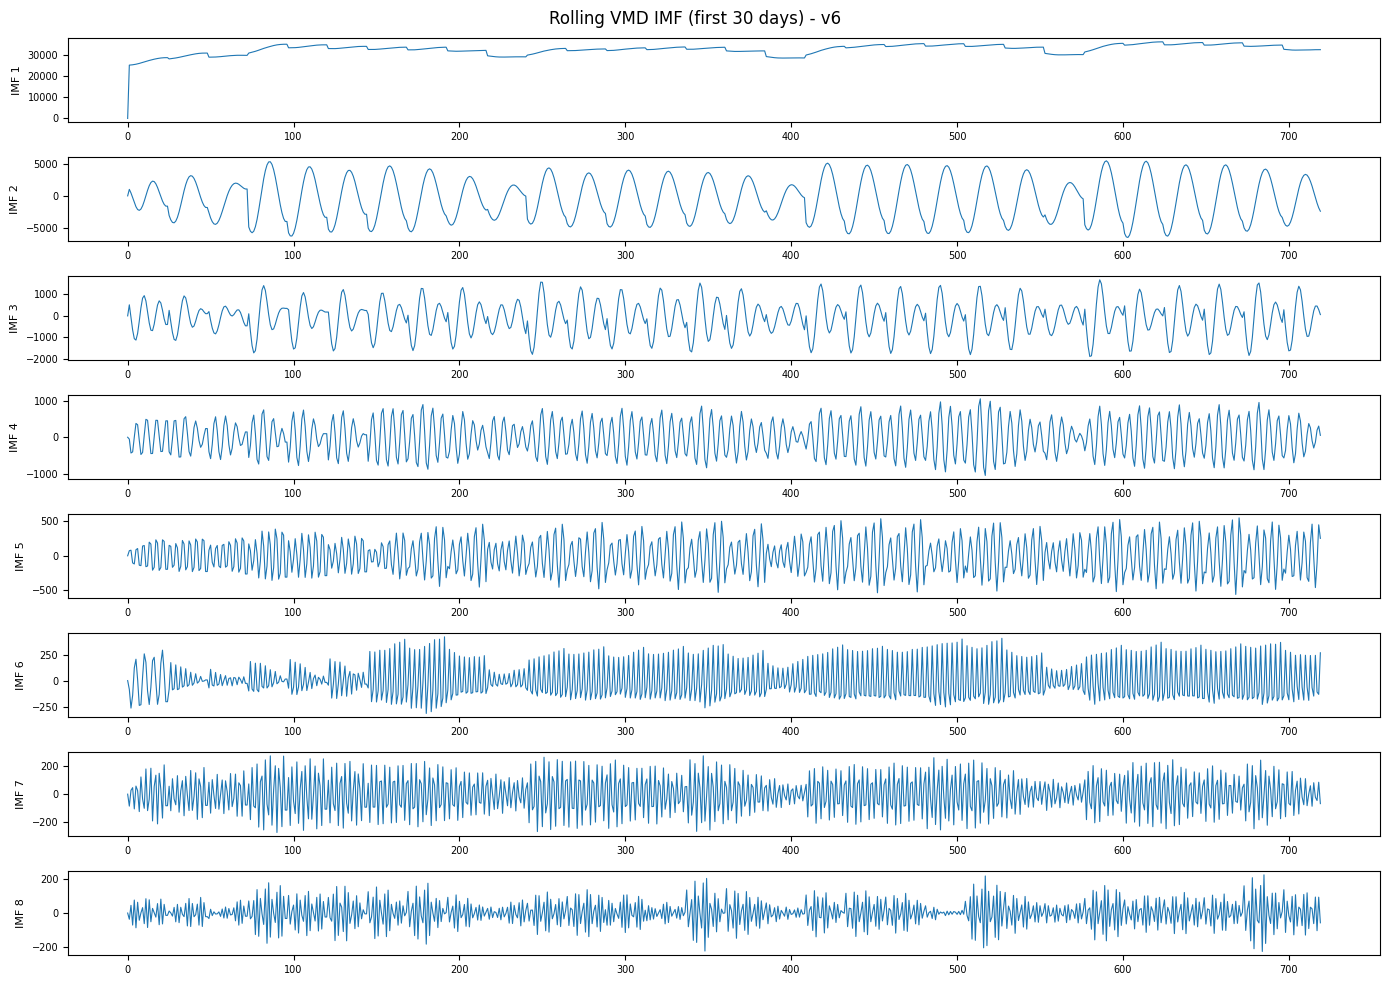

In [22]:
signal     = df['actual_load_mwh'].values.astype(np.float64)
N          = len(signal)
K          = CFG['vmd_K']
WINDOW     = CFG['vmd_window']
STEP       = CFG['vmd_step']

imf_matrix = np.zeros((N, K), dtype=np.float32)

print('Rolling VMD basliyor... (N={}, window={}, step={})'.format(N, WINDOW, STEP))

anchor_indices = list(range(0, N, STEP))
if anchor_indices[-1] != N - 1:
    anchor_indices.append(N - 1)

prev_anchor = 0
gc_counter  = 0
for anchor in tqdm(anchor_indices, desc='Rolling VMD'):
    win_start     = max(0, anchor - WINDOW + 1)
    win_end       = anchor + 1
    window_signal = signal[win_start:win_end]
    if len(window_signal) < K * 2:
        prev_anchor = anchor + 1
        continue
    try:
        u, _, _ = VMD(window_signal, CFG['vmd_alpha'], CFG['vmd_tau'],
                      K, CFG['vmd_DC'], CFG['vmd_init'], CFG['vmd_tol'])
        fill_start = prev_anchor
        fill_end   = anchor + 1
        for k in range(K):
            imf_k  = u[k]
            offset = fill_start - win_start
            length = fill_end - fill_start
            vals   = imf_k[offset:offset + length]
            if len(vals) < length:
                vals = np.pad(vals, (0, length - len(vals)), mode='edge')
            imf_matrix[fill_start:fill_end, k] = vals[:length].astype(np.float32)
        del u
    except Exception as e:
        print('WARN anchor={}: {}'.format(anchor, e))
    prev_anchor  = anchor + 1
    gc_counter  += 1
    if gc_counter % 50 == 0:
        gc.collect()

for k in range(K):
    df['imf_{}'.format(k+1)] = imf_matrix[:, k]
del imf_matrix, signal
gc.collect()

print('Rolling VMD tamamlandi. {} IMF eklendi.'.format(K))

fig, axes = plt.subplots(K, 1, figsize=(14, 10))
for k in range(K):
    axes[k].plot(df['imf_{}'.format(k+1)].values[:720], linewidth=0.8)
    axes[k].set_ylabel('IMF {}'.format(k+1), fontsize=8)
    axes[k].tick_params(labelsize=7)
plt.suptitle('Rolling VMD IMF (first 30 days) - v6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'imf_plot.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
class LoadDataset(Dataset):
    def __init__(self, X, y):
        self.X = np.ascontiguousarray(X, dtype=np.float32)
        self.y = np.ascontiguousarray(y, dtype=np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.from_numpy(self.y[i])

def create_sequences(features, target, seq_len, pred_len):
    n_samples = len(target) - seq_len - pred_len + 1
    X = np.empty((n_samples, seq_len, features.shape[1]), dtype=np.float32)
    y = np.empty((n_samples, pred_len), dtype=np.float32)
    for i in range(n_samples):
        X[i] = features[i:i+seq_len]
        y[i] = target[i+seq_len:i+seq_len+pred_len]
    return X, y

imf_cols      = ['imf_{}'.format(k+1) for k in range(CFG['vmd_K'])]
weather_cols  = ['w_temperature', 'w_humidity', 'w_wind', 'w_ghi', 'w_dni']
lag_cols      = ['lag_24h', 'lag_168h', 'lag_24h_diff', 'lag_168h_diff',
                 'rolling_24h_mean', 'rolling_168h_mean', 'rolling_24h_std']
temp_int_cols = ['hdd', 'cdd', 'temp_sq', 'temp_x_hour_sin', 'temp_x_hour_cos']
calendar_cols = [
    'hour', 'day_of_week', 'month', 'weekend',
    'public_holiday', 'pre_holiday', 'post_holiday',
    'school_day', 'tariff_day', 'tariff_peak', 'tariff_night',
    'peak_hour', 'ramadan_flag',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos',
]
ptf_cols = [
    'ptf_tl', 'ptf_usd', 'ptf_log',
    'ptf_lag_24h', 'ptf_lag_168h', 'ptf_diff_24h',
    'ptf_rolling_24h_mean', 'ptf_rolling_24h_std', 'ptf_rolling_168h_mean',
    'ptf_x_load',
]
feature_cols = imf_cols + weather_cols + lag_cols + temp_int_cols + calendar_cols + ptf_cols
feature_cols = [c for c in feature_cols if c in df.columns]

print('Feature groups (v7 + PTF):')
print('  IMF:      {}'.format(len([c for c in imf_cols      if c in df.columns])))
print('  Weather:  {}'.format(len([c for c in weather_cols  if c in df.columns])))
print('  Lag:      {}'.format(len([c for c in lag_cols      if c in df.columns])))
print('  Temp Int: {}'.format(len([c for c in temp_int_cols if c in df.columns])))
print('  Calendar: {}'.format(len([c for c in calendar_cols if c in df.columns])))
print('  PTF:      {}'.format(len([c for c in ptf_cols      if c in df.columns])))
print('  TOTAL:    {}'.format(len(feature_cols)))

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['actual_load_mwh'].values.astype(np.float32)

n_total = len(X_raw)
n_train = int(n_total * CFG['train_ratio'])
n_val   = int(n_total * CFG['val_ratio'])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
scaler_X.fit(X_raw[:n_train])
scaler_y.fit(y_raw[:n_train].reshape(-1, 1))

X_sc = scaler_X.transform(X_raw).astype(np.float32)
y_sc = scaler_y.transform(y_raw.reshape(-1, 1)).flatten().astype(np.float32)

print('Creating sequences...')
X, y     = create_sequences(X_sc, y_sc, CFG['seq_len'], CFG['pred_len'])
n        = len(X)
n_train2 = int(n * CFG['train_ratio'])
n_val2   = int(n * CFG['val_ratio'])

del X_sc, y_sc
gc.collect()

train_loader = DataLoader(LoadDataset(X[:n_train2], y[:n_train2]),
                          batch_size=CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(LoadDataset(X[n_train2:n_train2+n_val2], y[n_train2:n_train2+n_val2]),
                          batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(LoadDataset(X[n_train2+n_val2:], y[n_train2+n_val2:]),
                          batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

n_features = X.shape[2]
print('Train={:,} | Val={:,} | Test={:,} | Features={}'.format(n_train2, n_val2, n-n_train2-n_val2, n_features))

Feature groups (v7 + PTF):
  IMF:      8
  Weather:  2
  Lag:      7
  Temp Int: 0
  Calendar: 19
  PTF:      10
  TOTAL:    46
Creating sequences...
Train=62,227 | Val=13,334 | Test=13,336 | Features=46


In [24]:
y_train_raw      = y_raw[:n_train]
GLOBAL_Q_HIGH    = float(np.quantile(y_train_raw, CFG['peak_threshold']))
GLOBAL_Q_LOW     = float(np.quantile(y_train_raw, 1 - CFG['peak_threshold']))
GLOBAL_Q_HIGH_SC = float(scaler_y.transform([[GLOBAL_Q_HIGH]])[0][0])
GLOBAL_Q_LOW_SC  = float(scaler_y.transform([[GLOBAL_Q_LOW]])[0][0])

print('Peak threshold:   {:.1f} MWh'.format(GLOBAL_Q_HIGH))
print('Valley threshold: {:.1f} MWh'.format(GLOBAL_Q_LOW))

class PeakAwareLoss(nn.Module):
    def __init__(self, q_high, q_low, weight=1.5):
        super().__init__()
        self.q_high = q_high
        self.q_low  = q_low
        self.weight = weight
        self.huber  = nn.HuberLoss(reduction='none')
    def forward(self, pred, target):
        base        = self.huber(pred, target)
        peak_mask   = (target >= self.q_high).float()
        valley_mask = (target <= self.q_low).float()
        weight      = 1.0 + self.weight * (peak_mask + valley_mask)
        return (base * weight).mean()

print('PeakAwareLoss ready.')

Peak threshold:   40138.2 MWh
Valley threshold: 28039.1 MWh
PeakAwareLoss ready.


In [25]:
class PatchEmbedding(nn.Module):
    def __init__(self, seq_len, patch_size, stride, n_features, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.stride     = stride
        self.n_patches  = (seq_len - patch_size) // stride + 1
        self.proj       = nn.Linear(patch_size * n_features, d_model)
        self.norm       = nn.LayerNorm(d_model)
    def forward(self, x):
        patches = [x[:, i*self.stride:i*self.stride+self.patch_size, :].reshape(x.size(0), -1)
                   for i in range(self.n_patches)]
        return self.norm(self.proj(torch.stack(patches, dim=1)))

class PatchTST(nn.Module):
    def __init__(self, seq_len, n_features, pred_len, patch_size, stride,
                 d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.patch_embed = PatchEmbedding(seq_len, patch_size, stride, n_features, d_model)
        n_patches        = self.patch_embed.n_patches
        self.pos_embed   = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)
        self.head_1h  = nn.Sequential(
            nn.Linear(n_patches*d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, 1)
        )
        self.head_24h = nn.Sequential(
            nn.Linear(n_patches*d_model, d_model*2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model*2, d_model), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x, mode='24h'):
        x = self.dropout(self.patch_embed(x) + self.pos_embed)
        x = self.norm(self.transformer(x)).reshape(x.size(0), -1)
        return self.head_1h(x) if mode == '1h' else self.head_24h(x)

    def get_attention_weights(self, x):
        x = self.dropout(self.patch_embed(x) + self.pos_embed)
        weights = []
        for layer in self.transformer.layers:
            x_norm = layer.norm1(x)
            _, w = layer.self_attn(x_norm, x_norm, x_norm,
                                   need_weights=True, average_attn_weights=True)
            weights.append(w.detach().cpu())
            x = layer(x)
        return weights

model = PatchTST(
    seq_len=CFG['seq_len'], n_features=n_features, pred_len=CFG['pred_len'],
    patch_size=CFG['patch_size'], stride=CFG['stride'], d_model=CFG['d_model'],
    n_heads=CFG['n_heads'], n_layers=CFG['n_layers'], dropout=CFG['dropout']
).to(DEVICE)

print('Model parameters: {:,}'.format(sum(p.numel() for p in model.parameters())))
print('Patch count: {}'.format(model.patch_embed.n_patches))

N_GPU = torch.cuda.device_count()
if N_GPU > 1:
    print('Using {} GPUs with DataParallel'.format(N_GPU))
    model = nn.DataParallel(model)
else:
    print('Single GPU mode')

def model_forward(x, mode='24h'):
    base = model.module if isinstance(model, nn.DataParallel) else model
    if N_GPU <= 1:
        return base.forward(x, mode=mode)
    return nn.parallel.data_parallel(base, (x,), module_kwargs={'mode': mode})

def model_attention(x):
    base = model.module if isinstance(model, nn.DataParallel) else model
    return base.get_attention_weights(x)

Model parameters: 10,552,153
Patch count: 82
Using 2 GPUs with DataParallel


In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)

def lr_lambda(epoch):
    warmup = CFG['warmup_epochs']
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (CFG['epochs'] - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = PeakAwareLoss(q_high=GLOBAL_Q_HIGH_SC, q_low=GLOBAL_Q_LOW_SC, weight=CFG['peak_weight'])
print('LR schedule: warmup {}ep -> cosine decay'.format(CFG['warmup_epochs']))

best_val     = float('inf')
patience_cnt = 0
tr_losses    = []
val_losses   = []

epoch_bar = tqdm(range(CFG['epochs']), desc='Training', unit='epoch')

for epoch in epoch_bar:
    model.train()
    tl = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = (0.7 * criterion(model_forward(Xb, '24h'), yb)
                + 0.3 * criterion(model_forward(Xb, '1h'), yb[:, 0:1]))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            vl += (0.7 * criterion(model_forward(Xb, '24h'), yb)
                   + 0.3 * criterion(model_forward(Xb, '1h'), yb[:, 0:1])).item()

    tl /= len(train_loader)
    vl /= len(val_loader)
    tr_losses.append(tl)
    val_losses.append(vl)
    scheduler.step()

    if vl < best_val:
        best_val     = vl
        patience_cnt = 0
        best_state   = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(best_state, OUTPUT_DIR + 'best_model.pt')
    else:
        patience_cnt += 1

    epoch_bar.set_postfix({
        'Train':    '{:.4f}'.format(tl),
        'Val':      '{:.4f}'.format(vl),
        'Best':     '{:.4f}'.format(best_val),
        'Patience': '{}/{}'.format(patience_cnt, CFG['patience']),
        'Progress': '%{:.0f}'.format((epoch+1)/CFG['epochs']*100)
    })

    if patience_cnt >= CFG['patience']:
        print('Early stopping: {} epoch'.format(epoch+1))
        break

print('Training complete! Best Val Loss: {:.4f}'.format(best_val))

LR schedule: warmup 5ep -> cosine decay


Training:   0%|          | 0/120 [00:00<?, ?epoch/s]

Early stopping: 36 epoch
Training complete! Best Val Loss: 0.0317


In [27]:
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.load_state_dict(torch.load(OUTPUT_DIR + 'best_model.pt', map_location=DEVICE, weights_only=True))
model.eval()

preds, actuals = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model_forward(Xb.to(DEVICE), '24h').cpu().numpy())
        actuals.append(yb.numpy())

preds   = np.concatenate(preds,   axis=0)
actuals = np.concatenate(actuals, axis=0)
pi = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
ai = scaler_y.inverse_transform(actuals.reshape(-1,1)).reshape(actuals.shape)

mae  = np.mean(np.abs(pi - ai))
rmse = np.sqrt(np.mean((pi - ai)**2))
mape = np.mean(np.abs((ai - pi) / (ai + 1e-8))) * 100

flat_ai   = ai.flatten()
flat_pi   = pi.flatten()
q85       = np.quantile(flat_ai, 0.85)
peak_mask = flat_ai >= q85
mape_peak = np.mean(np.abs((flat_ai[peak_mask] - flat_pi[peak_mask]) / (flat_ai[peak_mask] + 1e-8))) * 100

print('Overall MAE:  {:,.2f} MWh'.format(mae))
print('Overall RMSE: {:,.2f} MWh'.format(rmse))
print('Overall MAPE: {:.2f}%'.format(mape))
print('Peak    MAPE: {:.2f}%  (ust %15)'.format(mape_peak))

Overall MAE:  986.51 MWh
Overall RMSE: 1,324.47 MWh
Overall MAPE: 2.41%
Peak    MAPE: 3.57%  (ust %15)


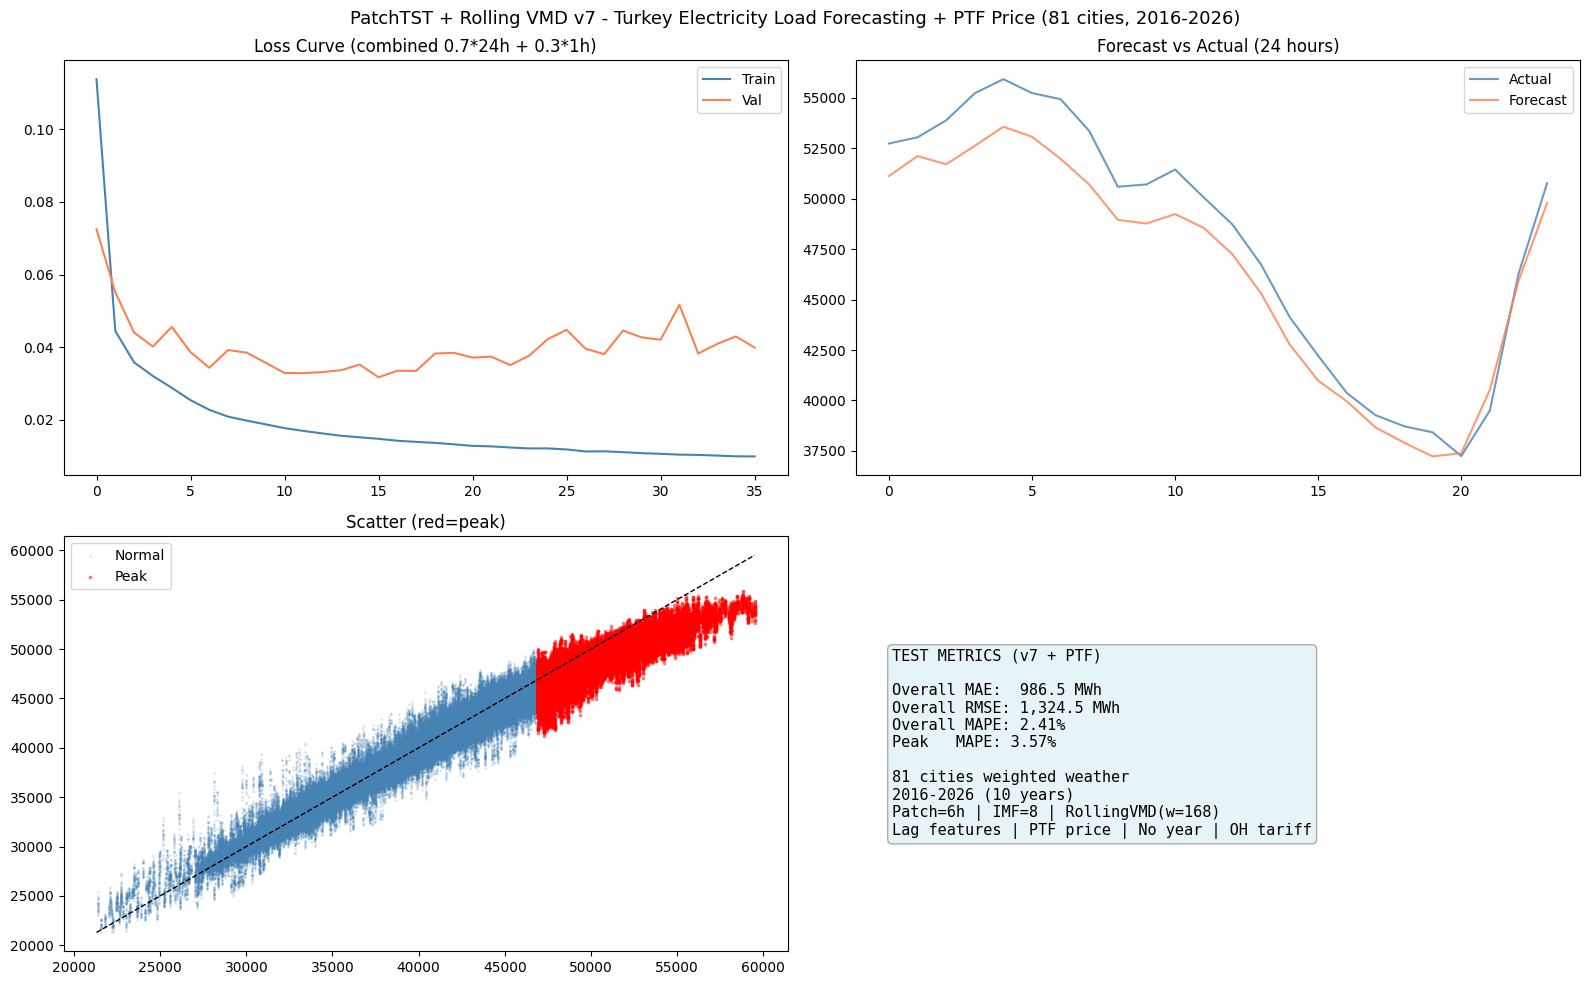

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PatchTST + Rolling VMD v7 - Turkey Electricity Load Forecasting + PTF Price (81 cities, 2016-2026)', fontsize=13)

axes[0,0].plot(tr_losses,  label='Train', color='steelblue')
axes[0,0].plot(val_losses, label='Val',   color='coral')
axes[0,0].set_title('Loss Curve (combined 0.7*24h + 0.3*1h)'); axes[0,0].legend()

n = min(24, len(pi.flatten()))
axes[0,1].plot(ai.flatten()[:n], label='Actual',   color='steelblue', alpha=0.8)
axes[0,1].plot(pi.flatten()[:n], label='Forecast', color='coral',     alpha=0.8)
axes[0,1].set_title('Forecast vs Actual (24 hours)'); axes[0,1].legend()

fp, fa  = pi.flatten(), ai.flatten()
q85     = np.quantile(fa, 0.85)
nm      = fa < q85
pm      = fa >= q85
axes[1,0].scatter(fa[nm], fp[nm], alpha=0.15, s=1, color='steelblue', label='Normal')
axes[1,0].scatter(fa[pm], fp[pm], alpha=0.4,  s=3, color='red',       label='Peak')
mn, mx = min(fa.min(), fp.min()), max(fa.max(), fp.max())
axes[1,0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
axes[1,0].set_title('Scatter (red=peak)'); axes[1,0].legend()

axes[1,1].axis('off')
axes[1,1].text(0.05, 0.5,
    'TEST METRICS (v7 + PTF)\n\n'
    'Overall MAE:  {:,.1f} MWh\n'.format(mae) +
    'Overall RMSE: {:,.1f} MWh\n'.format(rmse) +
    'Overall MAPE: {:.2f}%\n'.format(mape) +
    'Peak   MAPE: {:.2f}%\n\n'.format(mape_peak) +
    '81 cities weighted weather\n'
    '2016-2026 (10 years)\n'
    'Patch={}h | IMF={} | RollingVMD(w={})\n'.format(CFG['patch_size'], CFG['vmd_K'], CFG['vmd_window']) +
    'Lag features | PTF price | No year | OH tariff',
    transform=axes[1,1].transAxes, fontsize=11,
    verticalalignment='center', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3)
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'results_v6.png', dpi=150, bbox_inches='tight')
plt.show()

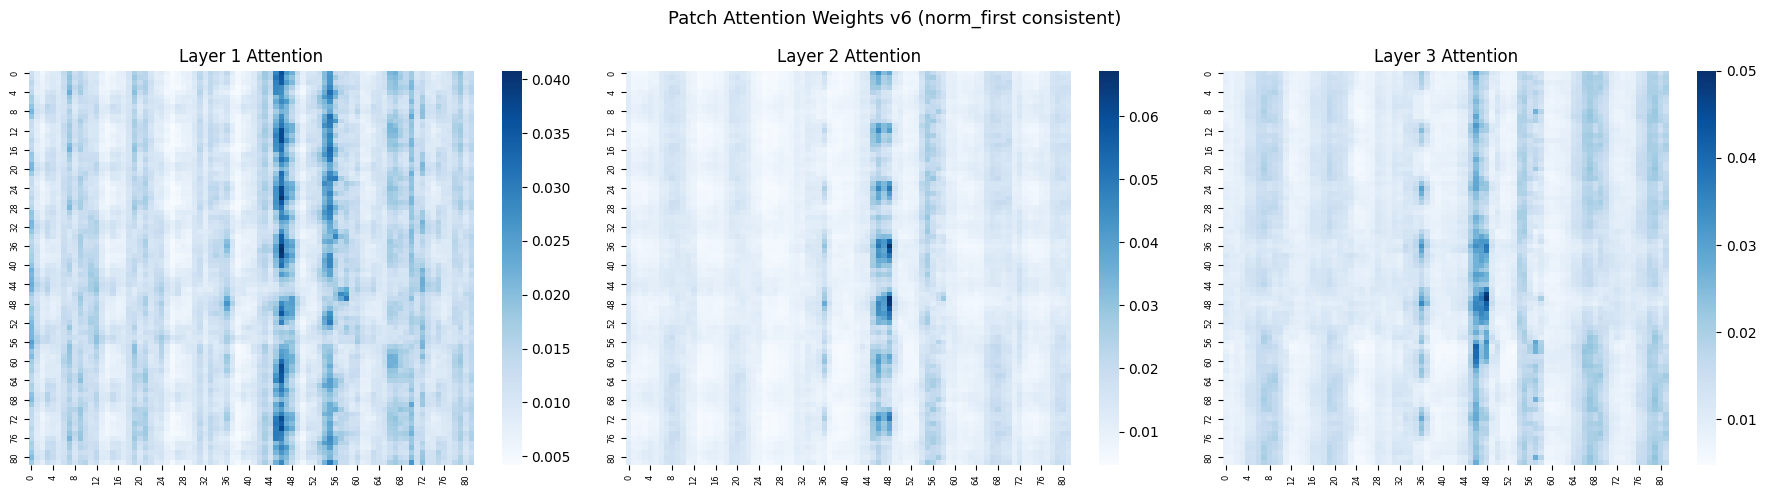

In [29]:
sample_X, _ = next(iter(test_loader))
model.eval()
with torch.no_grad():
    weights = model_attention(sample_X[0].unsqueeze(0).to(DEVICE))

fig, axes = plt.subplots(1, len(weights), figsize=(6*len(weights), 5))
if len(weights) == 1: axes = [axes]
for i, (w, ax) in enumerate(zip(weights, axes)):
    sns.heatmap(w[0].numpy(), ax=ax, cmap='Blues')
    ax.set_title('Layer {} Attention'.format(i+1))
    ax.tick_params(labelsize=6)
plt.suptitle('Patch Attention Weights v6 (norm_first consistent)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'attention_map_v6.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print('Output Files:')
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(OUTPUT_DIR + f) / 1024
    print('  {} ({:.1f} KB)'.format(f, size))
print('\nDownload from Kaggle Output tab.')

Output Files:
  .virtual_documents (4.0 KB)
  weather_weighted.csv (8612.9 KB)
  imf_plot.png (539.1 KB)
  best_model.pt (41238.7 KB)
  attention_map_v6.png (131.9 KB)
  results_v6.png (381.4 KB)

Download from Kaggle Output tab.
